In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image

In [12]:
dataset_path = "/kaggle/input/datasets/pankajkumarraj/brain-tumor-detection/brain_tumor_dataset_final/Training"
classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [13]:
data = []   #data overview

for cls in classes:
    
    class_path = os.path.join(dataset_path, cls)
    
    for img_name in os.listdir(class_path):
        
        img_path = os.path.join(class_path, img_name)
        
        data.append([img_path, cls])

df = pd.DataFrame(data, columns=["path","class"])

print("Total Images:", len(df))

df.head()

Total Images: 6628


,path,class
0,/kaggle/input/datasets/pankajkumarraj/brain-tu...,pituitary
1,/kaggle/input/datasets/pankajkumarraj/brain-tu...,pituitary
2,/kaggle/input/datasets/pankajkumarraj/brain-tu...,pituitary
3,/kaggle/input/datasets/pankajkumarraj/brain-tu...,pituitary
4,/kaggle/input/datasets/pankajkumarraj/brain-tu...,pituitary


class
glioma        2324
pituitary     1708
meningioma    1551
notumor       1045
Name: count, dtype: int64


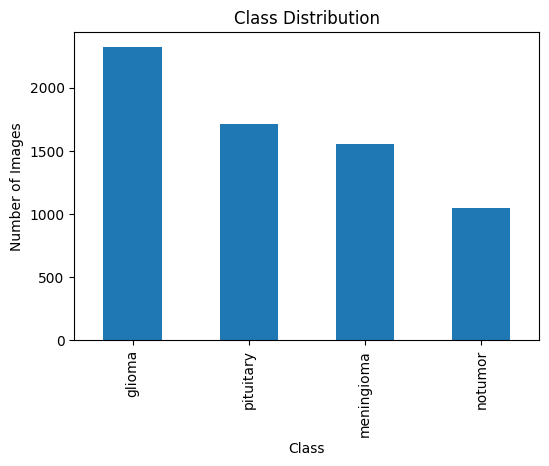

In [14]:
class_counts = df["class"].value_counts()  # classes distribution

print(class_counts)

plt.figure(figsize=(6,4))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

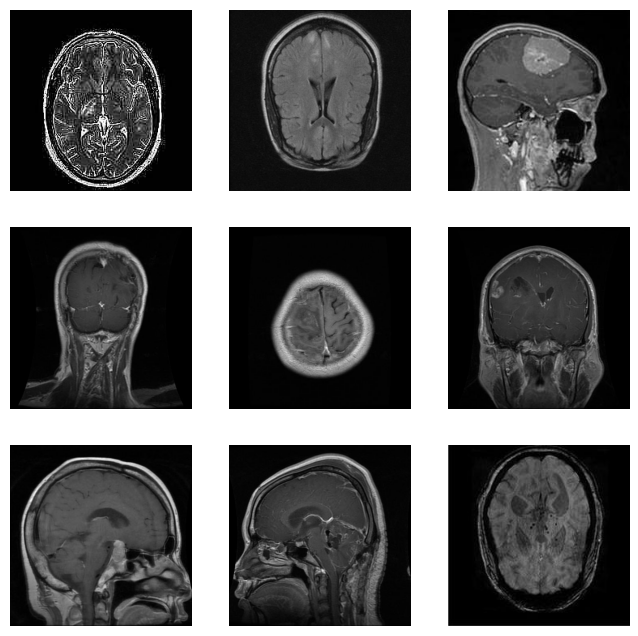

In [15]:
sample = random.sample(list(df["path"]), 9) # sample image visualization

plt.figure(figsize=(8,8))

for i,path in enumerate(sample):
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3,3,i+1)
    
    plt.imshow(img)
    
    plt.axis("off")

plt.show()

In [16]:
widths = []  # image resolution Anaylsis
heights = []

for path in df["path"]:
    
    with Image.open(path) as img:
        
        w,h = img.size
        
        widths.append(w)
        heights.append(h)

df["width"] = widths
df["height"] = heights

df[["width","height"]].describe()

,width,height
count,6628.000000,6628.000000
mean,404.580718,405.826946
std,145.854267,143.836738
min,150.000000,168.000000
25%,224.000000,224.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1375.000000,1446.000000


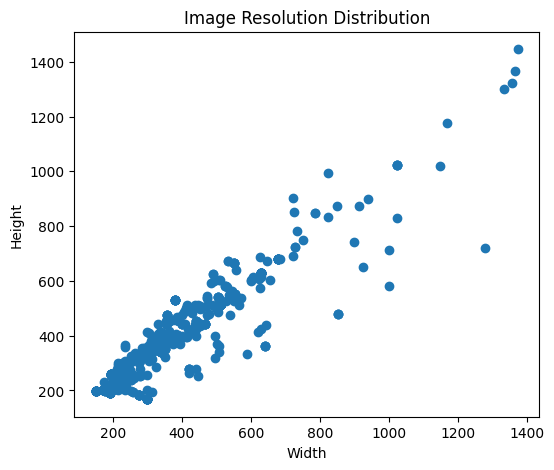

In [17]:
 plt.figure(figsize=(6,5)) # Resolution visualization

plt.scatter(df["width"], df["height"])

plt.title("Image Resolution Distribution")

plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [18]:
import hashlib   # duplicated image detection

def hash_file(path):
    
    with open(path,'rb') as f:
        
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["path"].apply(hash_file)

duplicates = df[df.duplicated("hash")]

print("Duplicate Images:", len(duplicates))

Duplicate Images: 0


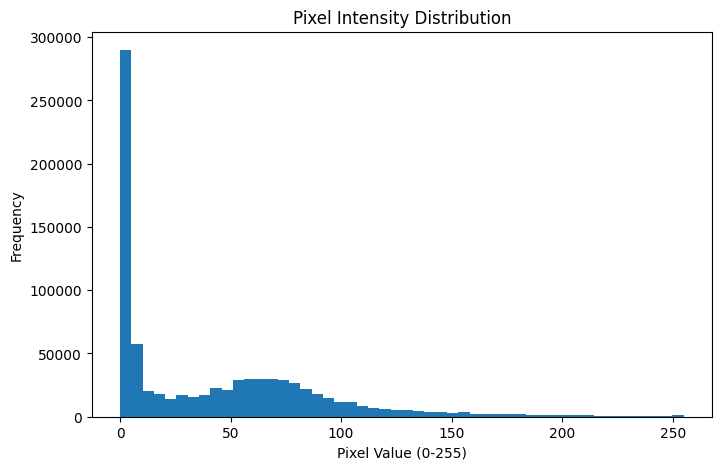

In [19]:
pixels = [] # Pixel intensity distribution

sample_size = min(200, len(df))

sample_paths = random.sample(list(df["path"]), sample_size)

for path in sample_paths:
    
    img = cv2.imread(path,0)
    
    if img is not None:
        
        img = cv2.resize(img,(64,64))
        
        pixels.extend(img.flatten())

plt.figure(figsize=(8,5))

plt.hist(pixels, bins=50)

plt.title("Pixel Intensity Distribution")

plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")

plt.show()

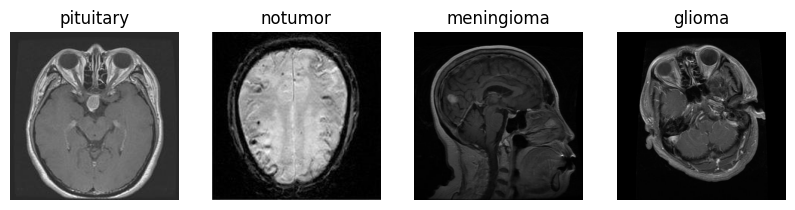

In [20]:
plt.figure(figsize=(10,5)) # classes vise sample image

for i,cls in enumerate(classes):
    
    path = df[df["class"]==cls]["path"].iloc[0]
    
    img = cv2.imread(path)
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1,len(classes),i+1)
    
    plt.imshow(img)
    
    plt.title(cls)
    
    plt.axis("off")

plt.show()

In [21]:
corrupted = [] # corrupted image detection

for path in df["path"]:
    try:
        img = cv2.imread(path)
        if img is None:
            corrupted.append(path)
    except:
        corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [22]:
img = cv2.imread(df["path"].iloc[0]) # image channel check
print("Image Shape:", img.shape)

Image Shape: (224, 224, 3)


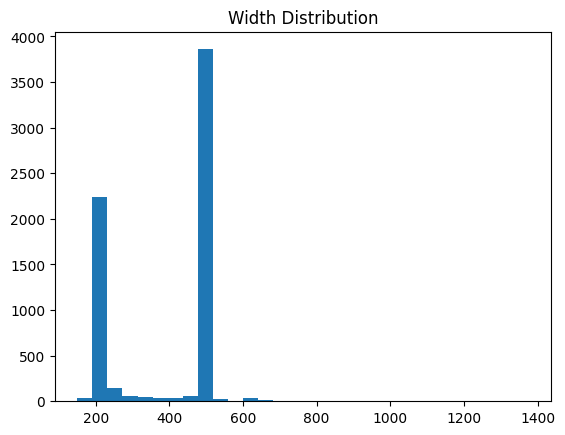

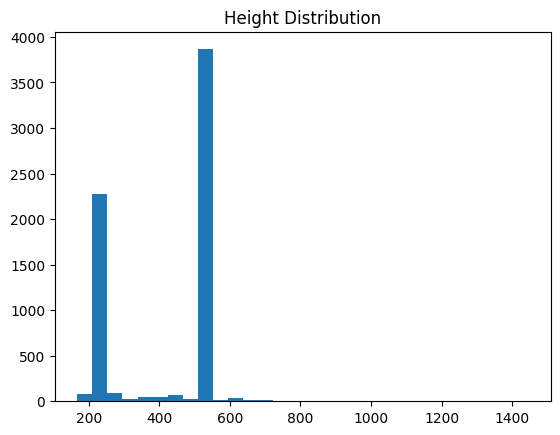

In [23]:
plt.hist(df["width"], bins=30) # image size distribution
plt.title("Width Distribution")
plt.show()

plt.hist(df["height"], bins=30)
plt.title("Height Distribution")
plt.show()

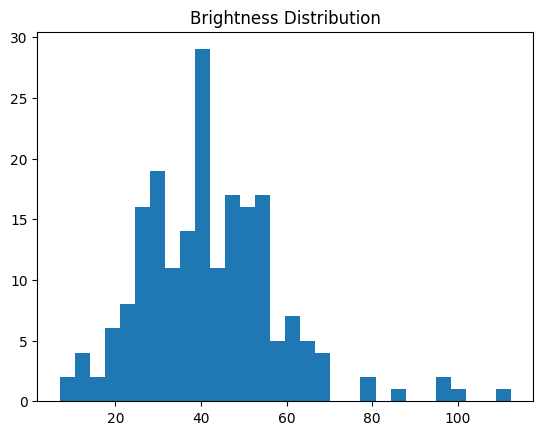

In [24]:
brightness = [] # brightness anyalsis

sample = df.sample(200)

for path in sample["path"]:
    img = cv2.imread(path,0)
    brightness.append(img.mean())

plt.hist(brightness, bins=30)

plt.title("Brightness Distribution")

plt.show()

In [25]:
print("===== DATASET EDA SUMMARY =====")

print("\nTotal Images:", len(df))

print("\nClasses:")
print(df["class"].unique())

print("\nClass Distribution:")
print(df["class"].value_counts())

print("\nImage Resolution Statistics:")
print(df[["width","height"]].describe())

print("\nMinimum Width:", df["width"].min())
print("Maximum Width:", df["width"].max())

print("\nMinimum Height:", df["height"].min())
print("Maximum Height:", df["height"].max())

print("\nDuplicate Images:", len(duplicates))

print("\nCorrupted Images:", len(corrupted))

===== DATASET EDA SUMMARY =====

Total Images: 6628

Classes:
['pituitary' 'notumor' 'meningioma' 'glioma']

Class Distribution:
class
glioma        2324
pituitary     1708
meningioma    1551
notumor       1045
Name: count, dtype: int64

Image Resolution Statistics:
             width       height
count  6628.000000  6628.000000
mean    404.580718   405.826946
std     145.854267   143.836738
min     150.000000   168.000000
25%     224.000000   224.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1375.000000  1446.000000

Minimum Width: 150
Maximum Width: 1375

Minimum Height: 168
Maximum Height: 1446

Duplicate Images: 0

Corrupted Images: 0
